In [1]:
from data_utils import *
from import_pkgs import *

In [5]:
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

def plot_bottom10_vertical_diff(city, city_ln):
    delta_T   = eval(f'{city}_test_T_avg_rev') - eval(f'{city}_rural_T_avg_rev')
    delta_PM  = eval(f'{city}_test_PM25_avg_rev') - eval(f'{city}_rural_PM25_avg_rev')
    delta_O3  = eval(f'{city}_test_O3_avg_rev') - eval(f'{city}_rural_O3_avg_rev')
    delta_NOx = eval(f'{city}_test_NOx_avg_rev') - eval(f'{city}_rural_NOx_avg_rev')
    delta_CO = eval(f'{city}_test_CO_avg_rev') - eval(f'{city}_rural_CO_avg_rev')

    levels = eval(f'{city}_pmid_rev')[0:10]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 6))
    
    for ax in (ax1, ax2):
        for lev in levels:
            ax.axhline(lev, color='grey', linewidth=0.5, linestyle='--', alpha=0.6)
    
    ax1.plot(zscore(delta_T)[0:10], levels,
             linestyle='-', color='#5b5b5b', linewidth=2, label=r'$\Delta T$')
    ax1.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax1.set_xlabel('Normalized $\Delta T$', fontsize=15)
    ax1.set_ylabel('Pressure level (hPa)', fontsize=15)
    ax1.tick_params(axis="x", labelsize=13)
    
    ax2.plot(zscore(delta_PM)[0:10],  levels,
             linestyle='-', color='#e06666', linewidth=2, label=r'$\Delta PM_{2.5}$')
    ax2.plot(zscore(delta_CO)[0:10], levels,
             linestyle='-', color='#6fa8dc', linewidth=2, label=r'$\Delta CO$')
    ax2.plot(zscore(delta_O3)[0:10],  levels,
             linestyle='-', color='#6aa84f', linewidth=2, label=r'$\Delta O_3$')
    ax2.plot(zscore(delta_NOx)[0:10], levels,
             linestyle='-', color='#f1c232', linewidth=2, label=r'$\Delta NO_x$')
    ax2.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax2.set_xlabel('Normalized $\Delta$pollutant', fontsize=15)
    ax2.legend(fontsize=13)
    ax2.tick_params(axis="x", labelsize=13)
    ax1.invert_yaxis()
    ax1.set_yticks(levels)
    ax1.set_yticklabels([f'{val:.1f}' for val in levels], fontsize=13)
    
    plt.suptitle(city_ln, fontsize=16, y=0.96, x=0.55)
    plt.tight_layout()

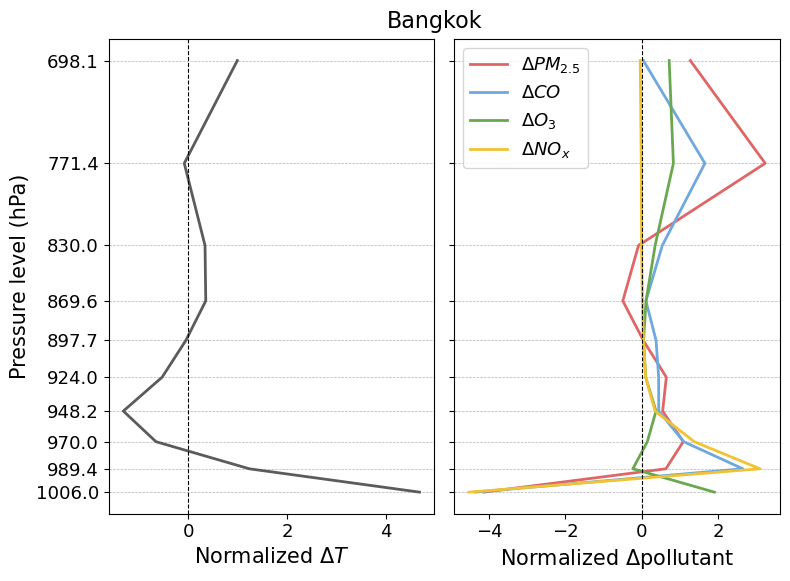

In [6]:
plot_bottom10_vertical_diff('bak', 'Bangkok')

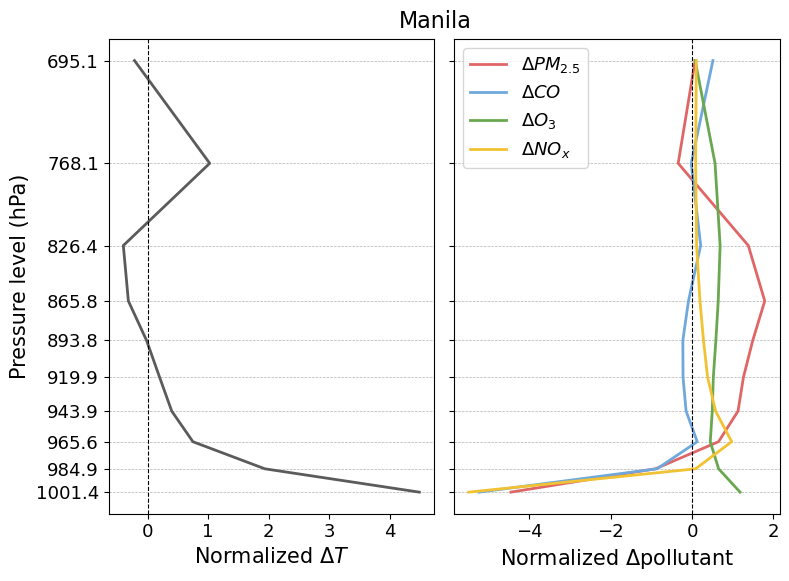

In [7]:
plot_bottom10_vertical_diff('mal', 'Manila')

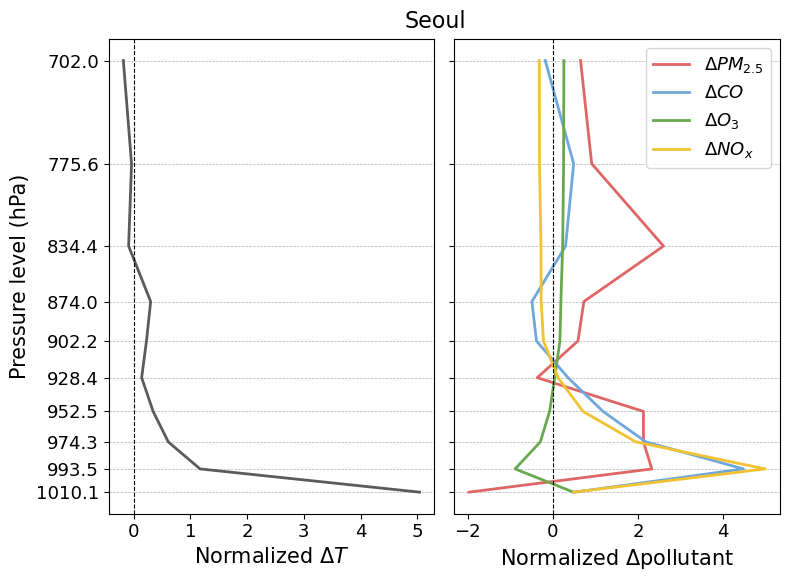

In [8]:
plot_bottom10_vertical_diff('seo', 'Seoul')

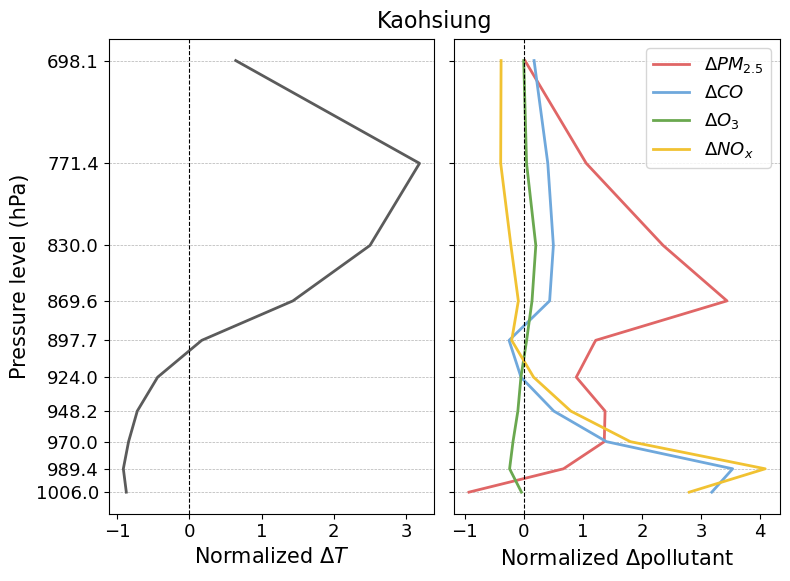

In [9]:
plot_bottom10_vertical_diff('kao', 'Kaohsiung')